In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import tensorflow as tf 
import keras
from keras import layers, models, optimizers, losses, callbacks
import torch
import matplotlib.pyplot as plt

In [3]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 32
TRAIN_DIR = "SkinDisease/Train"
VAL_DIR = "SkinDisease/Val"
TEST_DIR = "SkinDisease/Test"

In [ ]:
train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

val_data = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)
class_names = train_data.class_names
NUM_CLASSES = len(class_names)
print(f"\n[INFO] Detected Classes: {class_names}")
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.cache().prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)
test_data = test_data.cache().prefetch(buffer_size=AUTOTUNE)


--- Loading Datasets ---
Found 3000 files belonging to 6 classes.
Found 563 files belonging to 6 classes.
Found 324 files belonging to 6 classes.

[INFO] Detected Classes: ['Acne', 'Eczema', 'Psoriasis', 'SkinCancer', 'Unknown_Normal', 'Vitiligo']


In [5]:
def calculate_production_class_weights(directory, num_classes):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_dir = os.path.join(directory, class_name)
        if os.path.isdir(class_dir):
            class_counts[class_name] = len(os.listdir(class_dir))
    
    sorted_classes = sorted(class_counts.keys())
    counts = np.array([class_counts[cls] for cls in sorted_classes])
    total_samples = np.sum(counts)
    
    weights = total_samples / (num_classes * counts)
    return {i: weight for i, weight in enumerate(weights)}

class_weights_dict = calculate_production_class_weights(TRAIN_DIR, NUM_CLASSES)

In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.20, fill_mode="reflect"),
    layers.RandomZoom(0.10, fill_mode="reflect"),
    layers.RandomTranslation(0.1, 0.1, fill_mode="reflect"),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.1)
], name="advanced_medical_augmentation")


In [7]:
base_model = keras.applications.EfficientNetV2B3(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)

In [8]:
base_model.trainable = False

In [9]:
inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_layer")
x = data_augmentation(inputs)
x = base_model(x, training=False) 
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='swish', kernel_regularizer=keras.regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x) 

In [10]:
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name="predictions")(x)
model = models.Model(inputs, outputs)

In [11]:
loss_fn = losses.CategoricalCrossentropy(label_smoothing=0.05)
metrics_list = [
    keras.metrics.CategoricalAccuracy(name='accuracy'),
    keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_accuracy'),
    keras.metrics.Precision(name='precision'),
    keras.metrics.Recall(name='recall')
]

In [12]:
print("\n--- Phase 1: Warming up Classification Head ---")
model.compile(
    optimizer=optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=loss_fn,
    metrics=metrics_list
)


--- Phase 1: Warming up Classification Head ---


In [13]:
callbacks_phase1 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    callbacks.ModelCheckpoint('warmup_skin_model.keras', monitor='val_accuracy', save_best_only=True)
]

In [14]:
model.fit(
    train_data,
    epochs=5,
    validation_data=val_data,
    class_weight=class_weights_dict,
    callbacks=callbacks_phase1
)

Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 66s 686ms/step - accuracy: 0.6913 - loss: 1.2645 - precision: 0.7143 - recall: 0.6617 - top_5_accuracy: 0.9917 - val_accuracy: 0.6501 - val_loss: 1.0944 - val_precision: 0.8039 - val_recall: 0.5169 - val_top_5_accuracy: 0.9929
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 56s 595ms/step - accuracy: 0.7650 - loss: 0.8636 - precision: 0.8062 - recall: 0.7250 - top_5_accuracy: 0.9967 - val_accuracy: 0.6909 - val_loss: 1.0028 - val_precision: 0.7733 - val_recall: 0.6181 - val_top_5_accuracy: 0.9911
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 55s 585ms/step - accuracy: 0.8063 - loss: 0.7393 - precision: 0.8502 - recall: 0.7663 - top_5_accuracy: 0.9990 - val_accuracy: 0.6874 - val_loss: 1.0656 - val_precision: 0.7474 - val_recall: 0.6465 - val_top_5_accuracy: 0.9840
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 62s 660ms/step - accuracy: 0.8097 - loss: 0.7308 - precision: 0.8496 - recall: 0.7647 - top_5_accuracy: 0.9987 - val_accuracy: 0.7123 - val_loss: 1.0520 - val_precision: 0

In [ ]:
base_model.trainable = True


--- Phase 2: Unfreezing Entire Backbone for Maximum Accuracy ---


In [16]:
initial_learning_rate = 5e-5 
decay_steps = len(train_data) * 30 
lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    alpha=1e-2  
)

In [17]:
model.compile(
    optimizer=optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-3),
    loss=loss_fn,
    metrics=metrics_list
)

In [18]:
callbacks_phase2 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True), # زيادة الصبر لـ 8 لمنع التوقف قبل القمة
    callbacks.ModelCheckpoint('best_max_accuracy_model.keras', monitor='val_accuracy', save_best_only=True),
    callbacks.TensorBoard(log_dir='./logs_max_accuracy')
]

In [19]:
history = model.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
    class_weight=class_weights_dict,
    callbacks=callbacks_phase2
)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 510s 5s/step - accuracy: 0.6850 - loss: 1.1138 - precision: 0.7392 - recall: 0.6350 - top_5_accuracy: 0.9923 - val_accuracy: 0.5329 - val_loss: 1.3247 - val_precision: 0.6401 - val_recall: 0.4423 - val_top_5_accuracy: 0.9751
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 628s 7s/step - accuracy: 0.7610 - loss: 0.8741 - precision: 0.8097 - recall: 0.7207 - top_5_accuracy: 0.9980 - val_accuracy: 0.6821 - val_loss: 1.0447 - val_precision: 0.7692 - val_recall: 0.6039 - val_top_5_accuracy: 0.9734
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 632s 7s/step - accuracy: 0.8033 - loss: 0.7629 - precision: 0.8361 - recall: 0.7670 - top_5_accuracy: 0.9977 - val_accuracy: 0.6909 - val_loss: 1.0510 - val_precision: 0.7546 - val_recall: 0.6501 - val_top_5_accuracy: 0.9751
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 619s 7s/step - accuracy: 0.8373 - loss: 0.6823 - precision: 0.8707 - recall: 0.8010 - top_5_accuracy: 0.9983 - val_accuracy: 0.6945 - val_loss: 1.0836 - val_precision: 0.769


--- Evaluating Final Model on Test Set ---
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 678ms/step - accuracy: 0.6636 - loss: 1.3353 - precision: 0.6955 - recall: 0.6204 - top_5_accuracy: 0.9753
🎯 Test Accuracy Achieved: 66.36%


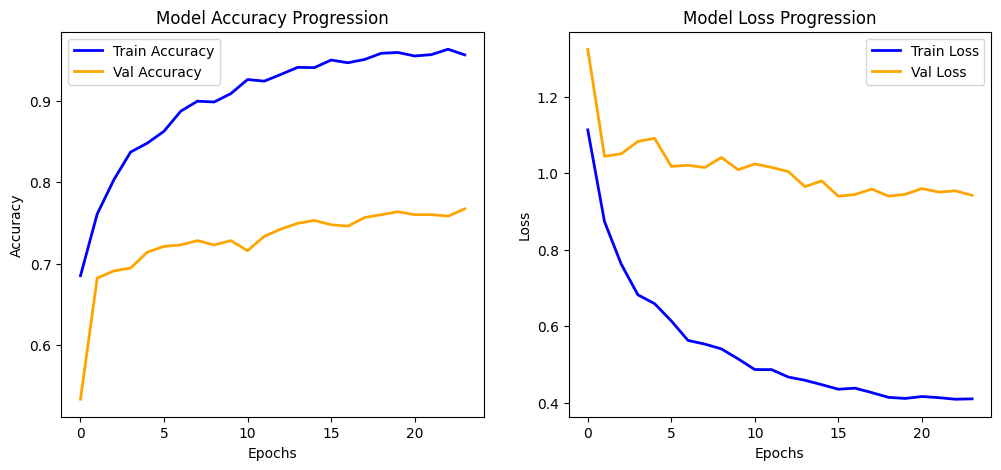

In [ ]:
test_results = model.evaluate(test_data)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy Progression')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
plt.title('Model Loss Progression')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:

test_results = model.evaluate(test_data)

print(f"Test Loss     : {test_results[0]:.4f}")
print(f"Test Accuracy : {test_results[1]*100:.2f}%")
print(f"Test Top-5 Acc: {test_results[2]*100:.2f}%")
print(f"Test Precision: {test_results[3]*100:.2f}%")
print(f"Test Recall   : {test_results[4]*100:.2f}%")


--- Evaluating Final Model on Test Set ---
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 925ms/step - accuracy: 0.6636 - loss: 1.3353 - precision: 0.6955 - recall: 0.6204 - top_5_accuracy: 0.9753
Test Loss     : 1.3353
Test Accuracy : 66.36%
Test Top-5 Acc: 97.53%
Test Precision: 69.55%
Test Recall   : 62.04%


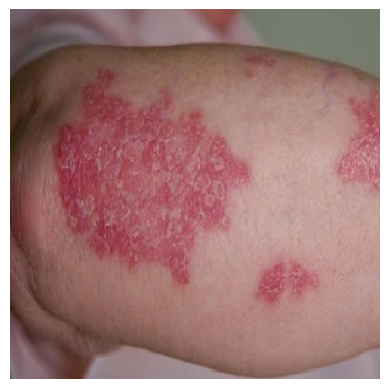

Prediction : Psoriasis
Confidence : 81.03%

Probabilities:
Acne           : 0.23%
Eczema         : 16.66%
Psoriasis      : 81.03%
SkinCancer     : 0.32%
Unknown_Normal : 1.15%
Vitiligo       : 0.61%


In [39]:
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt

img_path = "cc.jpg"   

img = keras.utils.load_img(img_path, target_size=IMG_SIZE)

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print(f"Prediction : {predicted_class}")
print(f"Confidence : {confidence:.2f}%")

print("\nProbabilities:")
for i, cls in enumerate(class_names):
    print(f"{cls:15s}: {prediction[0][i]*100:.2f}%")

In [ ]:
model.save("SkinScanAI_Model.keras")
from keras.models import load_model

model = load_model("SkinScanAI_Model.keras")

NameError: name 'model' is not defined